In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2025-02-23 14:47:49.459539: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-23 14:47:49.514788: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-23 14:47:49.541153: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740340069.609709     177 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740340069.623587     177 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-23 14:47:49.707022: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [217]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *
from sklearn.decomposition import PCA

In [204]:
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', 
                                                                         aTreatmentColumn = 'Hypothermia') 

/tmp/ipykernel_177/2726238241.py:6: DtypeWarning: Columns (14,16,41,51,63,65,66,76,80,89,99,111,113,114,124,128) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [ ]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10))]

In [ ]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 15.2min remaining:    0.0s


In [220]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(6000, activation='relu'), #6000
    layers.Dropout(0.5),#0.2
    layers.Dense(2000, activation='relu'),#2000
    layers.Dropout(0.1),#0.1
    # layers.Dense(1000, activation='relu'), 
    layers.Dense(500, activation='relu'), 
    layers.Dense(200, activation='relu'), 
    layers.Dense(50, activation='relu'), 
    layers.Dense(16, activation='relu'), 
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


In [221]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=30, batch_size=64, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.6329 - loss: 0.7204 - roc_auc: 0.6336 - val_accuracy: 0.6915 - val_loss: 0.5691 - val_roc_auc: 0.7572
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7864 - loss: 0.4713 - roc_auc: 0.8443 - val_accuracy: 0.7090 - val_loss: 0.5819 - val_roc_auc: 0.7656
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.8361 - loss: 0.3674 - roc_auc: 0.9124 - val_accuracy: 0.7102 - val_loss: 0.6166 - val_roc_auc: 0.7615
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8827 - loss: 0.3051 - roc_auc: 0.9402 - val_accuracy: 0.7052 - val_loss: 0.7420 - val_roc_auc: 0.7539
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.9142 - loss: 0.2302 - roc_auc: 0.9679 - val_accuracy: 0.6953 - val_loss: 0.7756 - val_roc_auc: 0.7608
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9322 - loss: 0.1765 - roc_auc: 0.9833 - val_accuracy: 0.7002 - val_loss: 0.9992 - val_roc_auc: 0.741

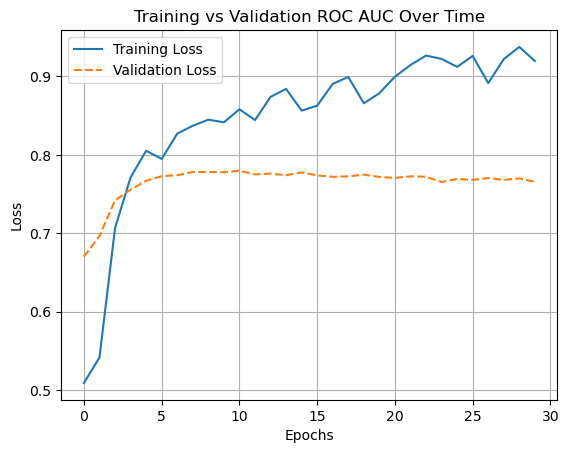

In [209]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [210]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
ROC AUC Score: 0.7659


In [52]:
y_pred_probs.T[0, :]

array([0.5073582 , 0.22482967, 0.64820576, ..., 0.7688423 , 0.5253298 ,
       0.16865435], dtype=float32)

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Optimization terminated successfully.
         Current function value: 0.659774
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.659495
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.0476465739534433
p-value: 0.30604972525557317
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 1875
Model:                          Logit   Df Residuals:                     1872
Method:                           MLE   Df Model:                            2
Date:                Sun, 23 Feb 2025   Pseudo R-squ.:                 0.01045
Time:                        17:51:13   Log-Likelihood:                -1237.1
converged:                       True   LL-Null:                       -1250.1
Covariance Type:    

0.30604972525557317

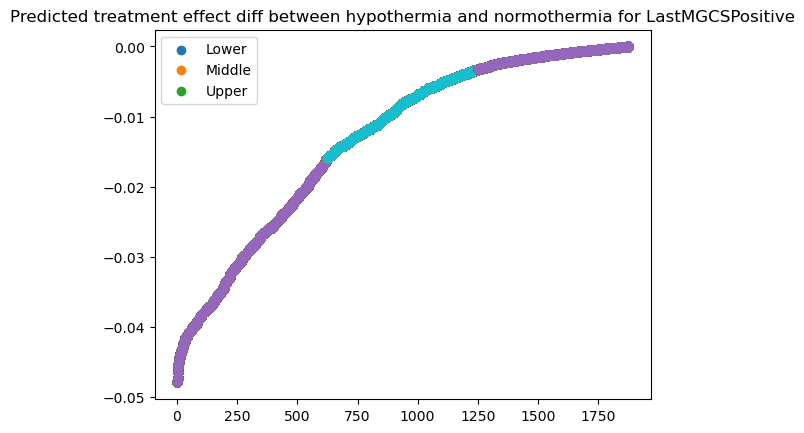

In [213]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'LastMGCSPositive', aGroup = 'bin__Hypothermia', aUseNeuralNetwork = True, aByGroup = False)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Optimization terminated successfully.
         Current function value: 0.690525
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.689652
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 1.7839063048706976
p-value: 0.40985446224475086
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                 1022
Model:                          Logit   Df Residuals:                     1018
Method:                           MLE   Df Model:                            3
Date:                Sun, 23 Feb 2025   Pseudo R-squ.:                0.002195
Time:                        17:29:35   Log-Likelihood:                -705.72
converged:                       True   LL-Null:                       -707.27
Covariance Type:     

0.40985446224475086

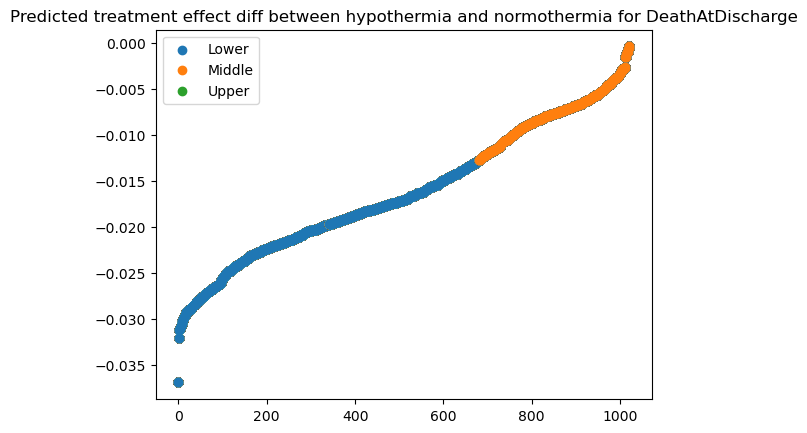

In [202]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'DeathAtDischarge', aGroup = 'bin__treatment_defibrillation', aUseNeuralNetwork = True, aByGroup =True)

In [193]:
[x for x in myPredictorsDf.columns if 'treatment' in x]

['treatment_5-10 cm H2O',
 'treatment_50-60%',
 'treatment_> 15 cm H2O',
 'treatment_>250 cc/hr',
 'treatment_>90%',
 'treatment_ACE inhibitor',
 'treatment_AFB',
 'treatment_BAL/PBS',
 'treatment_C A V H D',
 'treatment_C V V H D',
 'treatment_CABG',
 'treatment_CPAP/PEEP therapy',
 'treatment_CT scan',
 'treatment_Cardiac surgery consultation',
 'treatment_Cardiology consultation',
 "treatment_D5 Lactated Ringer's",
 'treatment_D50',
 'treatment_EEG',
 'treatment_EEG monitoring',
 'treatment_ERCP',
 'treatment_GI therapies',
 'treatment_Gastroenterology consultation',
 'treatment_HMG-CoA reductase inhibitor',
 'treatment_ICH/ cerebral infarct',
 'treatment_IV',
 'treatment_IV furosemide',
 'treatment_IVIG administration',
 'treatment_Infectious Disease consultation',
 "treatment_Lactated Ringer's administration",
 "treatment_Lactated Ringer's solution",
 'treatment_MRI - head',
 'treatment_Nephrology consultation',
 'treatment_Neurology consultation',
 'treatment_Neurosurgery consult